In [138]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import numpy as np

## Read Data

In [139]:
df_countries = pd.read_csv("./dataset/countries.csv", sep=';', decimal=',')
df_countries.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          165 non-null    str    
 1   child_mort       165 non-null    float64
 2   exports          165 non-null    float64
 3   health           165 non-null    float64
 4   imports          165 non-null    float64
 5   income           165 non-null    int64  
 6   inflation        165 non-null    float64
 7   life_expec       165 non-null    float64
 8   total_fer        165 non-null    float64
 9   gdpp             165 non-null    int64  
 10  income_category  165 non-null    str    
dtypes: float64(7), int64(2), str(2)
memory usage: 14.3 KB


## EDA

### Univariate Analysis

In [140]:
df_countries.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,38.567273,41.193327,6.825576,46.999793,17183.412121,7.585612,70.505455,2.959818,13011.963636
std,40.480851,27.560749,2.759425,24.233083,19389.968166,10.198185,8.935045,1.518166,18428.279743
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,7.900000,23.800000,4.930000,30.400000,3340.000000,1.770000,65.300000,1.800000,1310.000000
50%,19.700000,35.000000,6.320000,43.300000,9940.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.200000,51.400000,8.650000,58.900000,22900.000000,10.600000,76.800000,3.910000,14600.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


#### Income Category Distribution

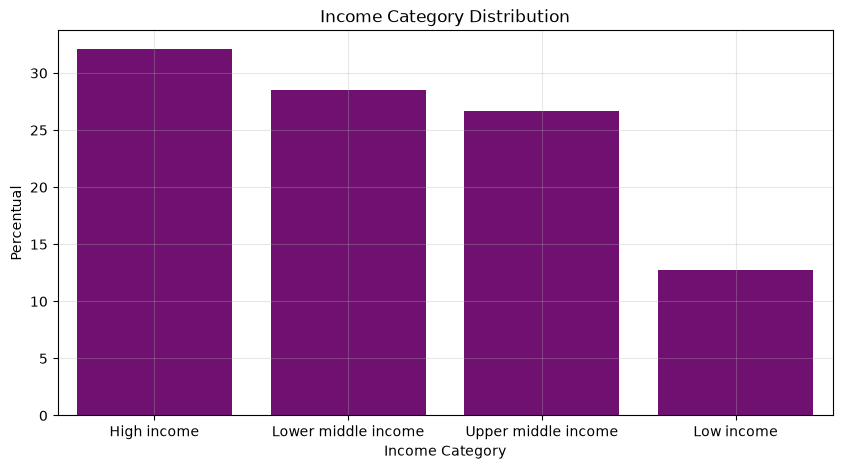

In [141]:
percentual = df_countries.value_counts('income_category', normalize=True) * 100 # type: ignore
plt.figure(figsize=(10,5))
sns.barplot(
  percentual, # type: ignore
  color='purple',
)
plt.ylabel('Percentual')
plt.xlabel("Income Category")
plt.title("Income Category Distribution")
plt.grid(visible=True, alpha=0.3)

#### Income Histogram

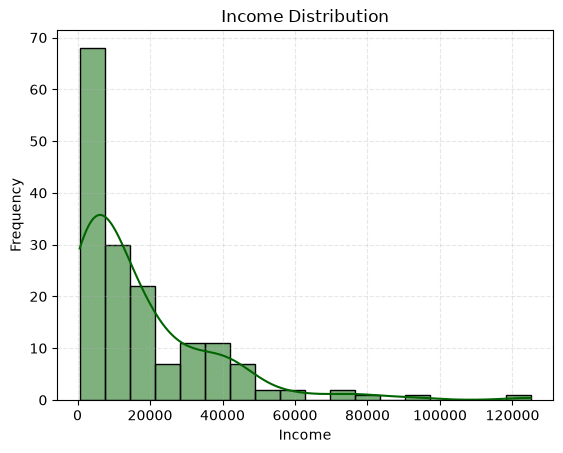

In [142]:
sns.histplot(
  data=df_countries,
  kde=True,
  x='income',
  color='darkgreen',
)
plt.title("Income Distribution")
plt.ylabel("Frequency")
plt.xlabel("Income")
plt.grid(alpha=0.3, visible=True, linestyle='--')

#### Gdpp Histogram

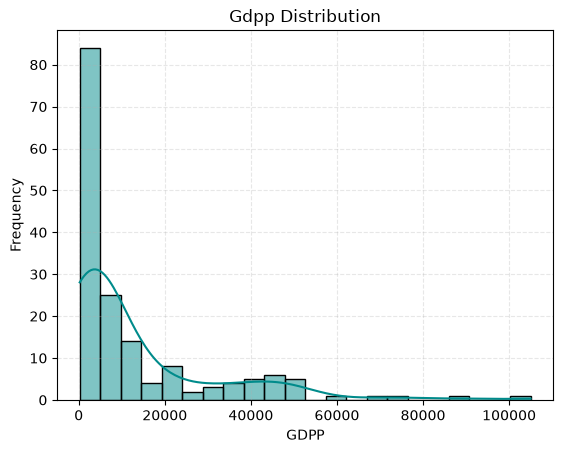

In [143]:
sns.histplot(
  data=df_countries,
  kde=True,
  x='gdpp',
  color='darkcyan',
)
plt.title("Gdpp Distribution")
plt.ylabel("Frequency")
plt.xlabel("GDPP")
plt.grid(alpha=0.3, visible=True, linestyle='--')

#### Inflation Histogram

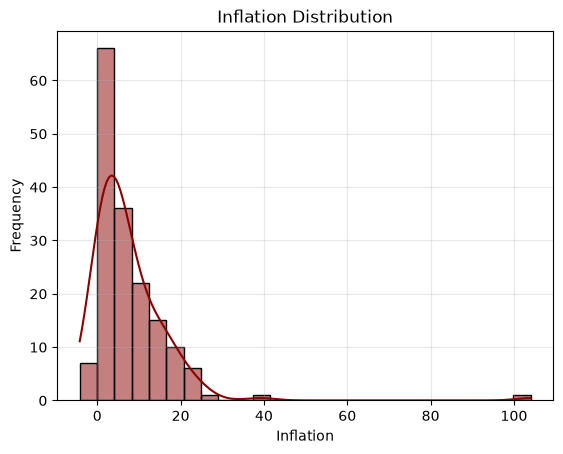

In [144]:
sns.histplot(
  data=df_countries,
  kde=True,
  x='inflation',
  color='darkred',
)
plt.title("Inflation Distribution")
plt.ylabel("Frequency")
plt.xlabel("Inflation")
plt.grid(alpha=0.3, visible=True)

#### Life Expectancy Histogram

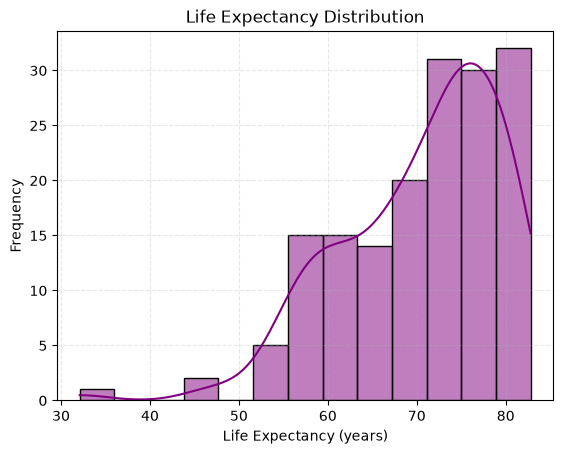

In [145]:
sns.histplot(
  data=df_countries,
  kde=True,
  x='life_expec',
  color='purple',
)
plt.title("Life Expectancy Distribution")
plt.ylabel("Frequency")
plt.xlabel("Life Expectancy (years)")
plt.grid(alpha=0.3, visible=True, linestyle='--')

###  Bivariate Analysis

#### Income Boxplot by Income Category

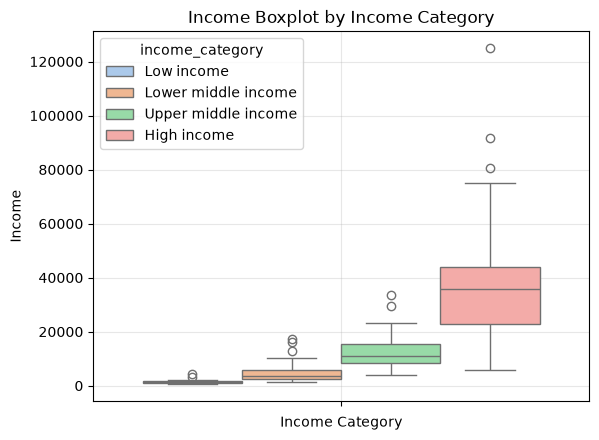

In [146]:
ax = sns.boxplot(
  data=df_countries,
  y='income',
  hue='income_category',
  hue_order=['Low income', 'Lower middle income', 'Upper middle income', 'High income'],
  palette='pastel',
)

plt.title("Income Boxplot by Income Category")
plt.ylabel("Income")
plt.xlabel("Income Category")
plt.grid(visible=True, alpha=0.3)

#### GDPP Boxplot by Income Category

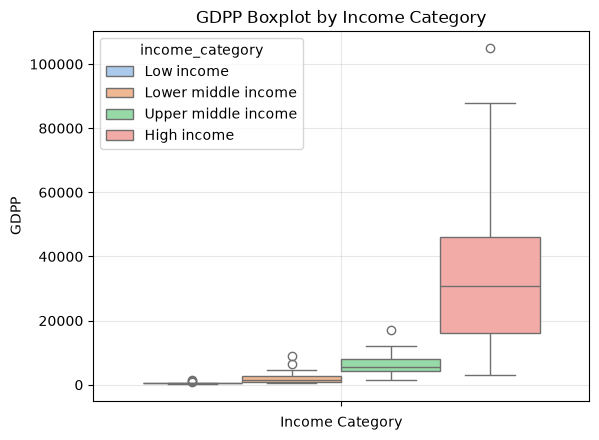

In [147]:
sns.boxplot(
  data=df_countries,
  y='gdpp',
  hue='income_category',
  palette='pastel',
  hue_order=['Low income', 'Lower middle income', 'Upper middle income', 'High income'],
)
plt.title("GDPP Boxplot by Income Category")
plt.ylabel("GDPP")
plt.xlabel("Income Category")
plt.grid(visible=True, alpha=0.3)

#### Inflation Boxplot by Income Category

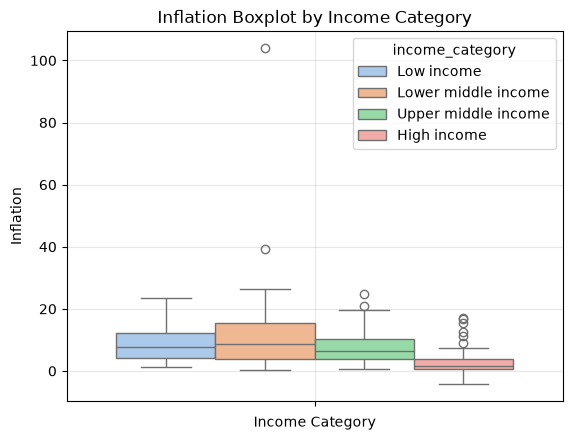

In [148]:
sns.boxplot(
  data=df_countries,
  y='inflation',
  hue='income_category',
  palette='pastel',
  hue_order=['Low income', 'Lower middle income', 'Upper middle income', 'High income'],
)
plt.title("Inflation Boxplot by Income Category")
plt.ylabel("Inflation")
plt.xlabel("Income Category")
plt.grid(visible=True, alpha=0.3)

#### Life Expectancy by Income Category

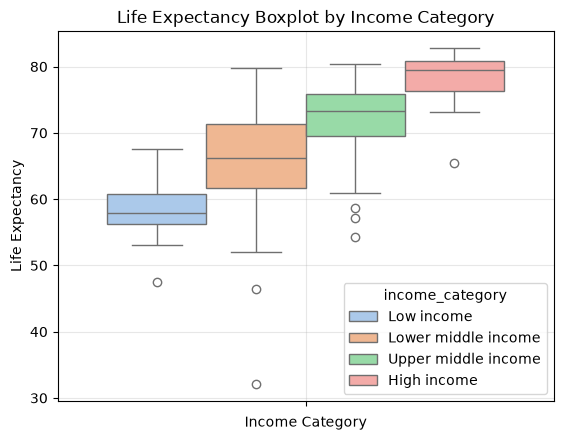

In [149]:
sns.boxplot(
  data=df_countries,
  y='life_expec',
  hue='income_category',
  palette='pastel',
  hue_order=['Low income', 'Lower middle income', 'Upper middle income', 'High income'],
)
plt.title("Life Expectancy Boxplot by Income Category")
plt.ylabel("Life Expectancy")
plt.xlabel("Income Category")
plt.grid(visible=True, alpha=0.3)

#### Scatterplot: Income x Gdpp

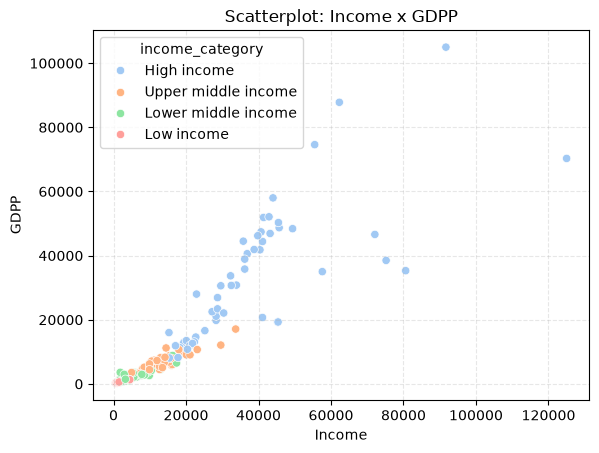

In [150]:
sns.scatterplot(
  data=df_countries,
  x='income',
  y='gdpp',
  hue='income_category',
  palette="pastel",
  hue_order=['High income', 'Upper middle income', 'Lower middle income', 'Low income'],
)
plt.title("Scatterplot: Income x GDPP")
plt.xlabel("Income")
plt.ylabel("GDPP")
plt.grid(visible=True, alpha=0.3, linestyle='--')

#### Correlação de Pearson

Text(0.5, 1.0, 'Pearson Correlation')

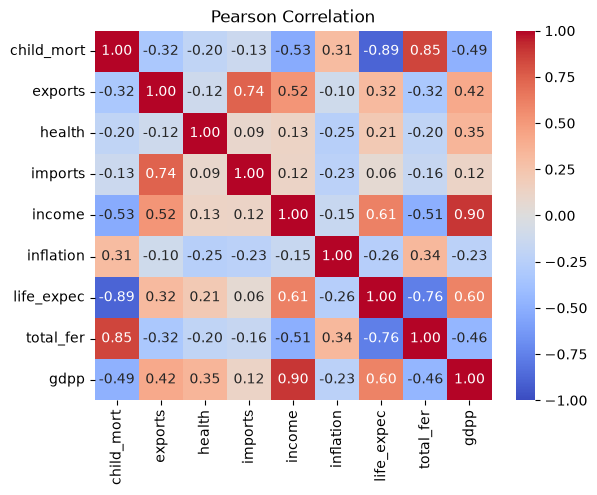

In [151]:
pearson_corr = df_countries.select_dtypes('number').corr("pearson")

sns.heatmap(
  pearson_corr,
  vmin=-1,
  vmax=1,
  cmap='coolwarm',
  annot=True,
  fmt=".2f"
)
plt.title("Pearson Correlation")

#### Correlação de Spearman

Text(0.5, 1.0, 'Spearman Correlation')

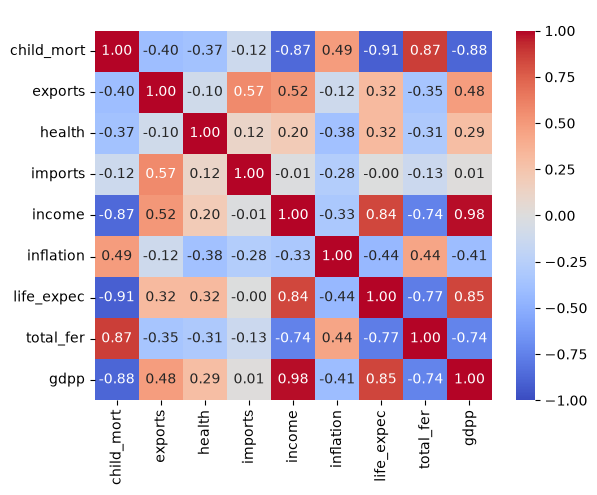

In [152]:
spearman_corr = df_countries.select_dtypes('number').corr("spearman")
sns.heatmap(
  spearman_corr,
  vmin=-1,
  vmax=1,
  cmap='coolwarm',
  annot=True,
  fmt=".2f",
)
plt.title("Spearman Correlation", color='white')

## Treinamento do modelo PCA

In [153]:
X = df_countries.copy()

X.drop(columns=['country', 'income_category'], inplace=True)

numeric_features = X.select_dtypes('number').columns.to_list()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
  ('num', numeric_transformer, numeric_features)
])

X_transformed = preprocessor.fit_transform(X=X)

model_PCA = PCA(n_components=3)

X_pca = model_PCA.fit_transform(X=X_transformed)

df_pca = pd.DataFrame(
  X_pca,
  columns=['PC1', 'PC2', 'PC3']
)

df_pca.to_csv('./dataset/pca.csv', index=False, sep=',')

df_countries = pd.concat([df_countries, df_pca], axis=1)

df_countries.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          165 non-null    str    
 1   child_mort       165 non-null    float64
 2   exports          165 non-null    float64
 3   health           165 non-null    float64
 4   imports          165 non-null    float64
 5   income           165 non-null    int64  
 6   inflation        165 non-null    float64
 7   life_expec       165 non-null    float64
 8   total_fer        165 non-null    float64
 9   gdpp             165 non-null    int64  
 10  income_category  165 non-null    str    
 11  PC1              165 non-null    float64
 12  PC2              165 non-null    float64
 13  PC3              165 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 18.2 KB


## Análise de Resultados

In [154]:
# Autovetores
autovetores = model_PCA.explained_variance_

# Autovalores
autovalores = model_PCA.components_

print(f"Autovetores: {autovetores}")
print(f"Autovalores: {autovalores}")

Autovetores: [4.18194258 1.55676483 1.15683401]
Autovalores: [[-0.41944537  0.28242091  0.15068193  0.16069962  0.39721431 -0.20064752
   0.42542863 -0.40370133  0.39213733]
 [ 0.18639458  0.61906392 -0.26537269  0.6623149   0.03301443  0.03814569
  -0.21355639  0.15172601 -0.04196516]
 [-0.02457745  0.11382205 -0.57151155 -0.33939771  0.32266099  0.63616571
   0.11811594  0.02417555  0.14584745]]


### Mostrar Chartd 3D com componentes principais

In [155]:
fig = px.scatter_3d(
  df_countries,
  x='PC1',
  y='PC2',
  z='PC3',
  color='income_category',
  title='PCA View',
  width=800,
  height=600,
  hover_data=['country'],
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Métrica de Recuperação de Dados

In [156]:
X_recovered = model_PCA.inverse_transform(X_pca)

X_recovered.shape # há 9 colunas de novo.

(165, 9)

In [157]:
reconstruction_error = mean_squared_error(X_transformed, X_recovered)
print(f"Erro de reconstrução: {reconstruction_error}")

Erro de reconstrução: 0.23847219349860976


## Salvar modelo e preprocessor

In [158]:
import joblib

joblib.dump(model_PCA, 'model-pca.pkl')
joblib.dump(preprocessor, 'preprocessor-pca.pkl')

['preprocessor-pca.pkl']